In [1]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path('data')


def read_data_csv(file_name, **kwargs):
    path = DATA_DIR / file_name
    if not path.exists():
        raise FileNotFoundError(f'Cannot find {path.resolve()}')
    return pd.read_csv(path, **kwargs)

In [2]:
df_deposit = read_data_csv('Data_Deposit.csv')
print('Data_Deposit.csv loaded successfully.')
display(df_deposit.head())

Data_Deposit.csv loaded successfully.


,MONTH,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,CUSTOMER_NUMBER
0,1/31/2019,1,246774.19,0,0.0,914393
1,2/28/2019,1,209207.36,0,0.0,914393
2,3/31/2019,1,213225.90,0,0.0,914393
3,4/30/2019,1,211761.87,0,0.0,914393
4,5/31/2019,1,222391.16,0,0.0,914393


In [3]:
df_card = read_data_csv('Data_Card.csv')
print('Data_Card.csv loaded successfully.')
display(df_card.head())

Data_Card.csv loaded successfully.


,MONTH,COUNT_CREDITCARD,COUNT_DEBITCARD,CUSTOMER_NUMBER
0,9/30/2019,0,1,914326
1,4/30/2019,0,1,914326
2,11/30/2019,0,1,914326
3,8/31/2019,0,1,914326
4,12/31/2019,0,1,914326


In [4]:
df_customer = read_data_csv('Data_Customer.csv', low_memory=False)
print('Data_Customer.csv loaded successfully.')
display(df_customer.head())

Data_Customer.csv loaded successfully.


,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
0,639362,M,4/23/2019,1/1/1996 0:00,N,4/23/2019,BRANCH,Y,SMS
1,452440,M,1/11/2019,10/10/1999 0:00,N,1/11/2019,BRANCH,Y,SMART_OTP
2,326290,F,5/27/2019,6/29/1996 0:00,N,5/27/2019,BRANCH,Y,SMS
3,20802,M,11/12/2019,8/7/1992 0:00,N,11/12/2019,BRANCH,Y,SMART_OTP
4,114244,M,3/29/2019,10/15/1973 0:00,N,3/29/2019,BRANCH,N,SMS


In [5]:
df_activity = read_data_csv('Data_Activity.csv')
print('Data_Activity.csv loaded successfully.')
display(df_activity.head())

Data_Activity.csv loaded successfully.


,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
0,1/22/2019,Tue,20,2,630178,MB_INTEREST_RATE_VIEW
1,1/10/2019,Thu,18,16,630178,MB_INTEREST_RATE_VIEW
2,1/26/2019,Sat,17,15,630178,MB_INTEREST_RATE_VIEW
3,1/2/2019,Wed,9,27,630178,MB_INTEREST_RATE_VIEW
4,1/19/2019,Sat,8,3,630178,MB_INTEREST_RATE_VIEW


In [6]:
df_transaction = read_data_csv('Data_Transaction.csv')
print('Data_Transaction.csv loaded successfully.')
display(df_transaction.head())

Data_Transaction.csv loaded successfully.


,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
0,Transfer,Outside_bank,2019-01-03,Thu,17,2,189771864.0,701619
1,Transfer,Outside_bank,2019-07-01,Mon,13,2,30224900.0,701619
2,Transfer,Outside_bank,2019-01-02,Wed,15,1,100000.0,701619
3,Payment,Credit_card_repayment,2019-01-03,Thu,14,1,85000000.0,262123
4,Payment,Credit_card_repayment,2019-01-28,Mon,22,1,83000000.0,262123


In [7]:
df_lending = read_data_csv('Data_Lending.csv')
print('Data_Lending.csv loaded successfully.')
display(df_lending.head())

Data_Lending.csv loaded successfully.


,MONTH,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
0,1/31/2019,1,15000000.0,811795
1,2/28/2019,1,13450000.0,811795
2,4/30/2019,1,14169673.0,811795
3,3/31/2019,1,12901665.0,811795
4,9/30/2019,1,13274815.0,811795


### Checking for Missing Values

In [8]:
print('Missing values in df_deposit:')
display(df_deposit.isnull().sum())

Missing values in df_deposit:


MONTH              0
COUNT_CA_ACCT      0
AVG_CA_BALANCE     0
COUNT_TD_ACCT      0
AVG_TD_BALANCE     0
CUSTOMER_NUMBER    0
dtype: int64

In [9]:
print('\nMissing values in df_card:')
display(df_card.isnull().sum())


Missing values in df_card:


MONTH               0
COUNT_CREDITCARD    0
COUNT_DEBITCARD     0
CUSTOMER_NUMBER     0
dtype: int64

In [10]:
print('\nMissing values in df_customer:')
display(df_customer.isnull().sum())


Missing values in df_customer:


CUSTOMER_NUMBER             0
CLIENT_SEX               4283
CLIENT_CREATE_DATE          0
DATE_OF_BIRTH            4289
STAFF                       0
IB_REGISTER_DATE       131248
EB_REGISTER_CHANNEL    131248
SMS                    131248
VERIFY_METHOD          131276
dtype: int64

cái này thì cứ thiếu sex là sẽ thiếu birth nên chỗ này em bỏ hết

---

4289 quan sát thiếu luôn

In [11]:
# Drop rows where 'DATE_OF_BIRTH' is missing in df_customer
df_customer_cleaned = df_customer.dropna(subset=['DATE_OF_BIRTH']).copy()

print(f"Original df_customer shape: {df_customer.shape}")
print(f"Cleaned df_customer_cleaned shape: {df_customer_cleaned.shape}")
print('\nMissing values in df_customer:')
display(df_customer_cleaned.isnull().sum())

Original df_customer shape: (290223, 9)
Cleaned df_customer_cleaned shape: (285934, 9)

Missing values in df_customer:


CUSTOMER_NUMBER             0
CLIENT_SEX                  0
CLIENT_CREATE_DATE          0
DATE_OF_BIRTH               0
STAFF                       0
IB_REGISTER_DATE       127003
EB_REGISTER_CHANNEL    127003
SMS                    127003
VERIFY_METHOD          127031
dtype: int64

In [12]:
print('\nMissing values in df_activity:')
display(df_activity.isnull().sum())


Missing values in df_activity:


ACTIVITY_DATE      0
DAY_OF_WEEK        0
ACTIVITY_HOUR      0
ACTIVITY_NO        0
CUSTOMER_NUMBER    0
ACTIVITY_NAME      0
dtype: int64

In [13]:
print('\nMissing values in df_transaction:')
display(df_transaction.isnull().sum())


Missing values in df_transaction:


TRANS_LV1          0
TRANS_LV2          0
TRANS_DATE         0
DAY_OF_WEEK        0
TRANS_HOUR         0
TRANS_NO           0
TRANS_AMOUNT       0
CUSTOMER_NUMBER    0
dtype: int64

In [14]:
print('\nMissing values in df_lending:')
display(df_lending.isnull().sum())


Missing values in df_lending:


MONTH              0
COUNT_OF_LOAN      0
AVG_LOAN_AMOUNT    0
CUSTOMER_NUMBER    0
dtype: int64

### Checking for Duplicated Rows

In [15]:
print('Duplicated rows in df_deposit:', df_deposit.duplicated().sum())

Duplicated rows in df_deposit: 0


In [16]:
print('Duplicated rows in df_card:', df_card.duplicated().sum())

Duplicated rows in df_card: 0


In [17]:
print('Duplicated rows in df_customer_cleaned:', df_customer_cleaned.duplicated().sum())

Duplicated rows in df_customer_cleaned: 0


In [18]:
print('Duplicated rows in df_activity:', df_activity.duplicated().sum())

Duplicated rows in df_activity: 0


In [19]:
print('Duplicated rows in df_transaction:', df_transaction.duplicated().sum())

Duplicated rows in df_transaction: 0


In [20]:
print('Duplicated rows in df_lending:', df_lending.duplicated().sum())

Duplicated rows in df_lending: 0


Không có file nào bị dính duplicated cả

### Checking for Outliers


Outliers for df_deposit:


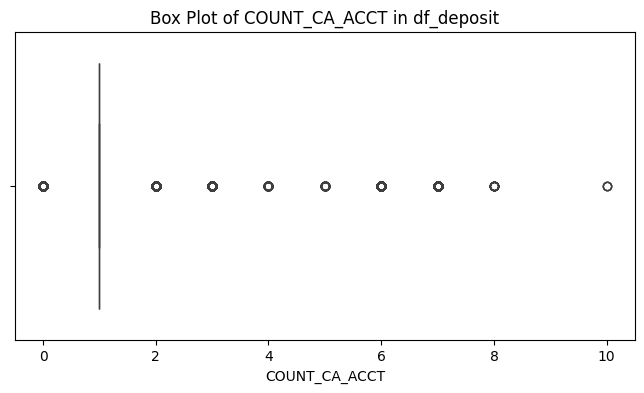

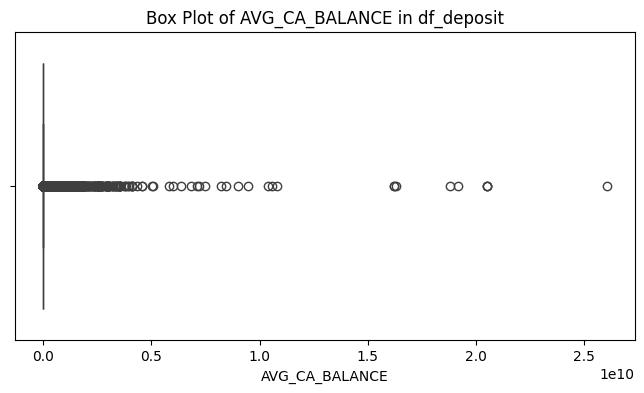

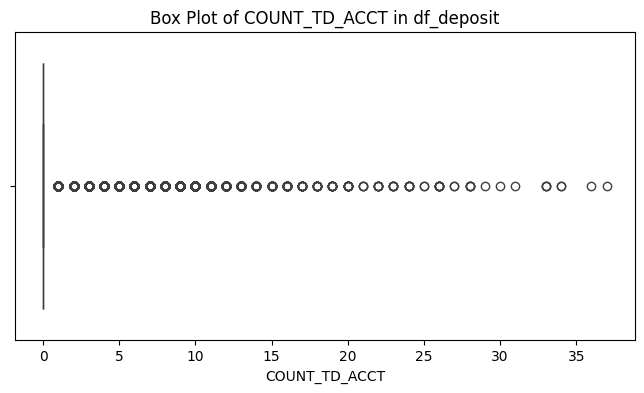

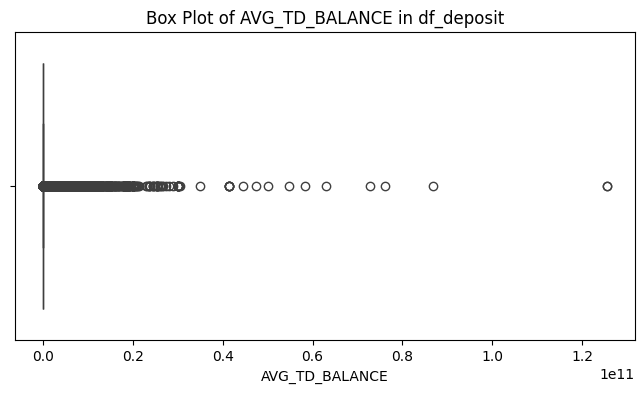


Outliers for df_card:


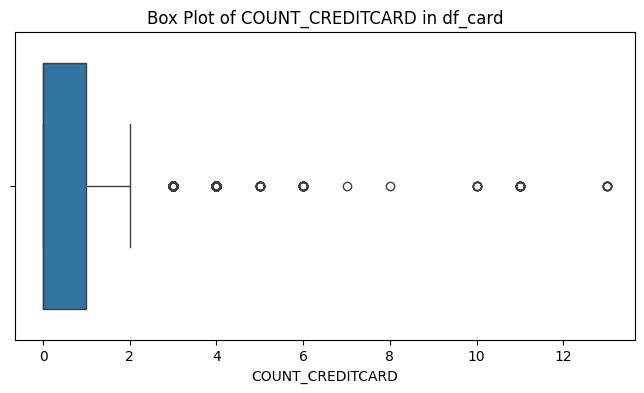

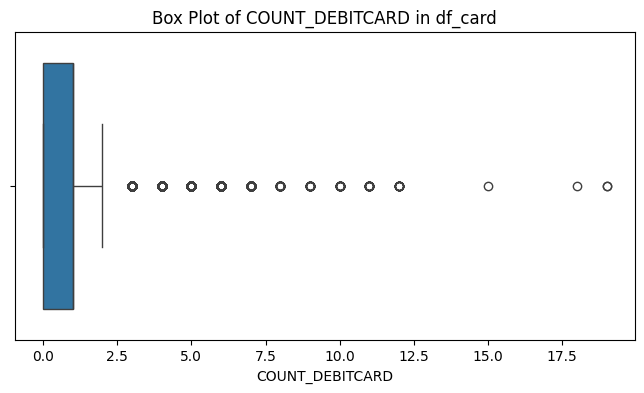

No suitable numerical columns found for outlier detection in df_customer_cleaned (excluding customer IDs).

Outliers for df_activity:


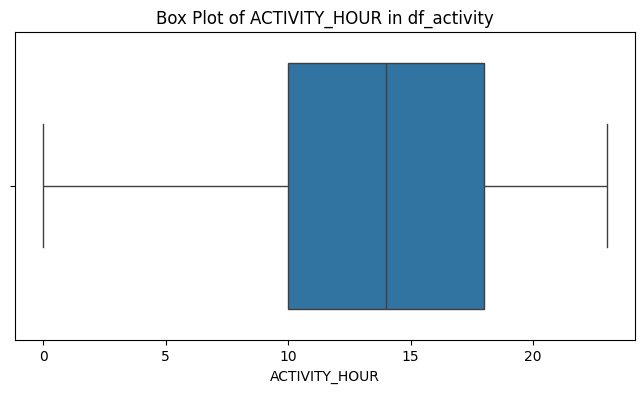

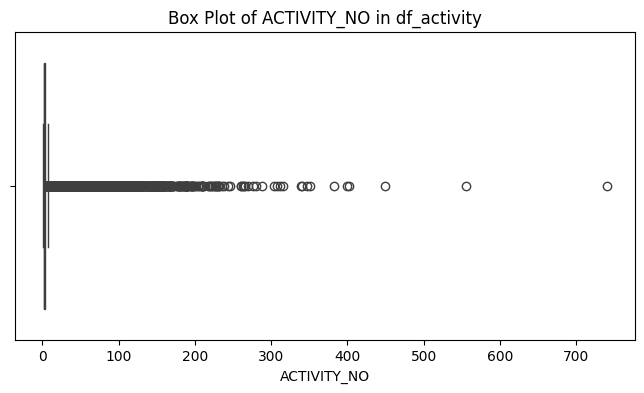


Outliers for df_transaction:


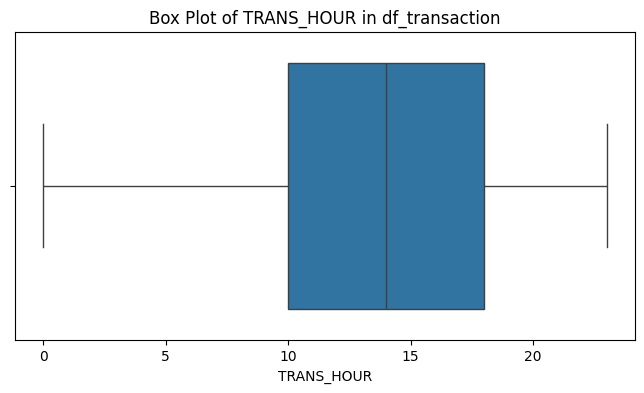

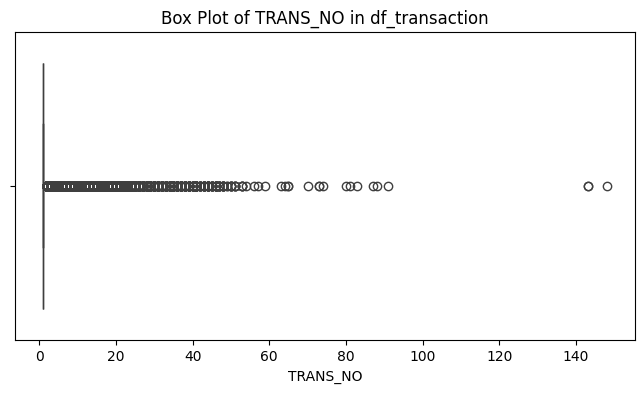

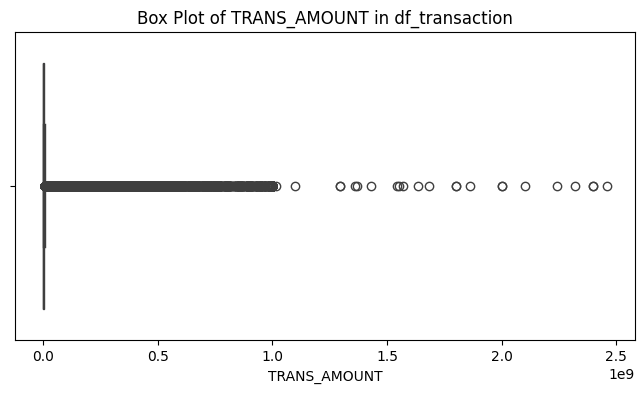


Outliers for df_lending:


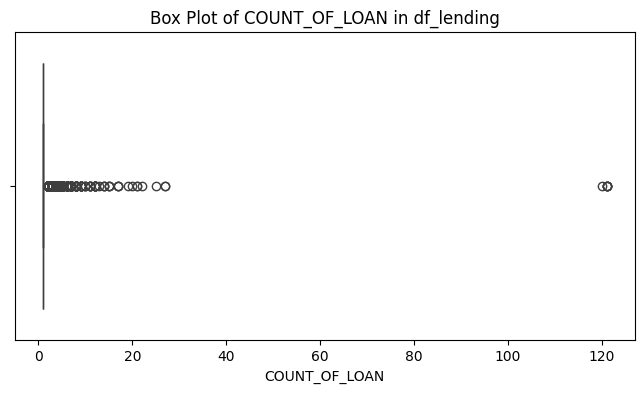

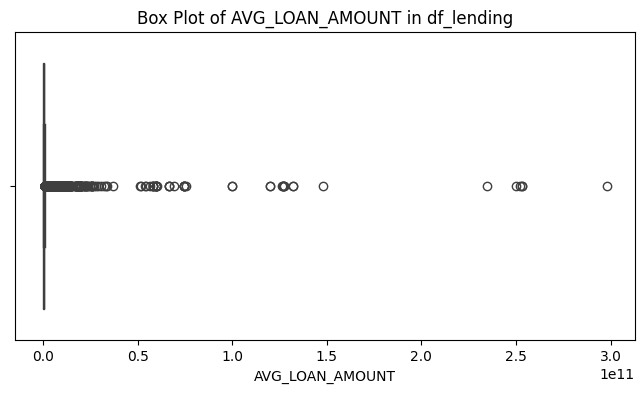

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numerical_outliers(df, df_name):
    numerical_cols = df.select_dtypes(include=['number']).columns
    customer_id_cols = [col for col in numerical_cols if 'CUSTOMER_NUMBER' in col.upper()]

    # Exclude customer ID columns from outlier plotting
    cols_to_plot = [col for col in numerical_cols if col not in customer_id_cols]

    if not cols_to_plot:
        print(f"No suitable numerical columns found for outlier detection in {df_name} (excluding customer IDs).")
        return

    print(f"\nOutliers for {df_name}:")

    for col in cols_to_plot:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot of {col} in {df_name}')
        plt.xlabel(col)
        plt.show()

# Check df_deposit
plot_numerical_outliers(df_deposit, 'df_deposit')

# Check df_card
plot_numerical_outliers(df_card, 'df_card')

# Check df_customer_cleaned
plot_numerical_outliers(df_customer_cleaned, 'df_customer_cleaned')

# Check df_activity
plot_numerical_outliers(df_activity, 'df_activity')

# Check df_transaction
plot_numerical_outliers(df_transaction, 'df_transaction')

# Check df_lending
plot_numerical_outliers(df_lending, 'df_lending')

### Investigating 'non-IB' Customers in Activity and Transaction Logs

In [22]:
# Identify 'non-IB' customers from df_customer_cleaned
# Assuming 'non-IB' customers are those with a missing IB_REGISTER_DATE
non_ib_customers = df_customer_cleaned[df_customer_cleaned['IB_REGISTER_DATE'].isnull()]

# Get the CUSTOMER_NUMBER for these non-IB customers
non_ib_customer_numbers = non_ib_customers['CUSTOMER_NUMBER'].unique()

print(f"Number of identified 'non-IB' customers: {len(non_ib_customer_numbers)}")

Number of identified 'non-IB' customers: 127003


In [23]:
# Check if these non-IB customer numbers exist in df_activity
non_ib_in_activity = df_activity[df_activity['CUSTOMER_NUMBER'].isin(non_ib_customer_numbers)]

print(f"Number of 'non-IB' customers found in df_activity: {non_ib_in_activity['CUSTOMER_NUMBER'].nunique()}")
print(f"Total activity logs for 'non-IB' customers: {len(non_ib_in_activity)}")
display(non_ib_in_activity.head())

Number of 'non-IB' customers found in df_activity: 0
Total activity logs for 'non-IB' customers: 0


,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME


In [24]:
# Check if these non-IB customer numbers exist in df_transaction
non_ib_in_transaction = df_transaction[df_transaction['CUSTOMER_NUMBER'].isin(non_ib_customer_numbers)]

print(f"Number of 'non-IB' customers found in df_transaction: {non_ib_in_transaction['CUSTOMER_NUMBER'].nunique()}")
print(f"Total transaction logs for 'non-IB' customers: {len(non_ib_in_transaction)}")
display(non_ib_in_transaction.head())

Number of 'non-IB' customers found in df_transaction: 3
Total transaction logs for 'non-IB' customers: 48


,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
89939,Payment,Credit_card_repayment,2019-03-11,Mon,8,1,72000.0,355259
89940,Payment,Credit_card_repayment,2019-05-30,Thu,10,1,150000000.0,355259
89941,Payment,Credit_card_repayment,2019-04-03,Wed,9,1,72000.0,355259
89942,Payment,Credit_card_repayment,2019-01-31,Thu,11,1,1299000.0,355259
89943,Payment,Credit_card_repayment,2019-03-07,Thu,16,1,62658744.0,355259


### Removing Inconsistent 'non-IB' Customer Data

In [25]:
# Remove activity logs belonging to 'non-IB' customers
initial_activity_rows = len(df_activity)
df_activity_cleaned = df_activity[~df_activity['CUSTOMER_NUMBER'].isin(non_ib_customer_numbers)].copy()

print(f"Original df_activity rows: {initial_activity_rows}")
print(f"df_activity rows after removing non-IB entries: {len(df_activity_cleaned)}")
print(f"Number of activity rows removed: {initial_activity_rows - len(df_activity_cleaned)}")

display(df_activity_cleaned.head())

Original df_activity rows: 1048575
df_activity rows after removing non-IB entries: 1048575
Number of activity rows removed: 0


,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
0,1/22/2019,Tue,20,2,630178,MB_INTEREST_RATE_VIEW
1,1/10/2019,Thu,18,16,630178,MB_INTEREST_RATE_VIEW
2,1/26/2019,Sat,17,15,630178,MB_INTEREST_RATE_VIEW
3,1/2/2019,Wed,9,27,630178,MB_INTEREST_RATE_VIEW
4,1/19/2019,Sat,8,3,630178,MB_INTEREST_RATE_VIEW


In [26]:
# Remove transaction logs belonging to 'non-IB' customers
initial_transaction_rows = len(df_transaction)
df_transaction_cleaned = df_transaction[~df_transaction['CUSTOMER_NUMBER'].isin(non_ib_customer_numbers)].copy()

print(f"Original df_transaction rows: {initial_transaction_rows}")
print(f"df_transaction rows after removing non-IB entries: {len(df_transaction_cleaned)}")
print(f"Number of transaction rows removed: {initial_transaction_rows - len(df_transaction_cleaned)}")

display(df_transaction_cleaned.head())

Original df_transaction rows: 1418030


df_transaction rows after removing non-IB entries: 1417982
Number of transaction rows removed: 48


,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
0,Transfer,Outside_bank,2019-01-03,Thu,17,2,189771864.0,701619
1,Transfer,Outside_bank,2019-07-01,Mon,13,2,30224900.0,701619
2,Transfer,Outside_bank,2019-01-02,Wed,15,1,100000.0,701619
3,Payment,Credit_card_repayment,2019-01-03,Thu,14,1,85000000.0,262123
4,Payment,Credit_card_repayment,2019-01-28,Mon,22,1,83000000.0,262123


The `df_activity_cleaned` and `df_transaction_cleaned` DataFrames now exclude the logs from the identified 'non-IB' customers. The original `df_activity` and `df_transaction` remain unchanged.

### Xuất các file vừa clean





In [27]:
from pathlib import Path

OUTPUT_DIR = Path('cleaned_data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def drop_unnamed_columns(df):
    cols = [c for c in df.columns if not str(c).startswith('Unnamed')]
    return df.loc[:, cols].copy()


def month_end(series):
    dt = pd.to_datetime(series, errors='coerce')
    return dt.dt.to_period('M').dt.to_timestamp('M')


def downcast_numeric(df):
    for col in df.select_dtypes(include=['int64', 'Int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    return df


def save_table(df, name):
    parquet_path = OUTPUT_DIR / f'{name}.parquet'
    csv_path = OUTPUT_DIR / f'{name}.csv'
    df.to_parquet(parquet_path, index=False)
    df.to_csv(csv_path, index=False)
    print(f'Saved {parquet_path}, {csv_path} shape={df.shape}')


customer_clean = drop_unnamed_columns(df_customer_cleaned)

if 'AGE' not in customer_clean.columns:
    import pandas as pd
    reference_date = pd.Timestamp('2020-01-01')
    dob = pd.to_datetime(customer_clean['DATE_OF_BIRTH'], errors='coerce')
    customer_clean['AGE'] = (reference_date - dob).dt.days / 365.25
    customer_clean['AGE'] = customer_clean['AGE'].fillna(customer_clean['AGE'].median())
if 'Occupation_Group' not in customer_clean.columns:
    customer_clean['Occupation_Group'] = 'UNKNOWN'
if 'Education_Level' not in customer_clean.columns:
    customer_clean['Education_Level'] = 'UNKNOWN'
if 'Marital_Status' not in customer_clean.columns:
    customer_clean['Marital_Status'] = 'UNKNOWN'
deposit_clean = drop_unnamed_columns(df_deposit)
lending_clean = drop_unnamed_columns(df_lending)
card_clean = drop_unnamed_columns(df_card)
activity_clean = drop_unnamed_columns(df_activity_cleaned)
transaction_clean = drop_unnamed_columns(df_transaction_cleaned)

if 'Device_ID_Hash' not in transaction_clean.columns:
    import numpy as np
    transaction_clean['Device_ID_Hash'] = np.nan
if 'Merchant_ID_Masked' not in transaction_clean.columns:
    import numpy as np
    transaction_clean['Merchant_ID_Masked'] = np.nan

for df in [deposit_clean, lending_clean, card_clean]:
    df['MONTH'] = month_end(df['MONTH'])

for col in ['CLIENT_CREATE_DATE', 'DATE_OF_BIRTH', 'IB_REGISTER_DATE']:
    customer_clean[col] = pd.to_datetime(customer_clean[col], errors='coerce')

activity_clean['ACTIVITY_DATE'] = pd.to_datetime(activity_clean['ACTIVITY_DATE'], errors='coerce')
activity_clean['MONTH'] = month_end(activity_clean['ACTIVITY_DATE'])

transaction_clean['TRANS_DATE'] = pd.to_datetime(transaction_clean['TRANS_DATE'], errors='coerce')
transaction_clean['MONTH'] = month_end(transaction_clean['TRANS_DATE'])
transaction_clean['IS_INTERNAL_TRANSFER'] = (transaction_clean['TRANS_LV2'] == 'Within_bank').astype('int8')

tables = {
    'customer_clean': downcast_numeric(customer_clean),
    'deposit_clean': downcast_numeric(deposit_clean),
    'lending_clean': downcast_numeric(lending_clean),
    'card_clean': downcast_numeric(card_clean),
    'transaction_clean': downcast_numeric(transaction_clean),
    'activity_clean': downcast_numeric(activity_clean),
}

for name, df in tables.items():
    save_table(df, name)

qa_df = pd.DataFrame([
    {
        'table': name,
        'rows': len(df),
        'cols': df.shape[1],
        'customer_nunique': df['CUSTOMER_NUMBER'].nunique(),
        'duplicate_rows': int(df.duplicated().sum()),
        'total_missing': int(df.isna().sum().sum()),
    }
    for name, df in tables.items()
])
display(qa_df)
qa_df.to_csv(OUTPUT_DIR / 'cleaning_qa_summary.csv', index=False)


Saved cleaned_data\customer_clean.parquet, cleaned_data\customer_clean.csv shape=(285934, 13)


Saved cleaned_data\deposit_clean.parquet, cleaned_data\deposit_clean.csv shape=(1258424, 6)


Saved cleaned_data\lending_clean.parquet, cleaned_data\lending_clean.csv shape=(576431, 4)


Saved cleaned_data\card_clean.parquet, cleaned_data\card_clean.csv shape=(871589, 4)


Saved cleaned_data\transaction_clean.parquet, cleaned_data\transaction_clean.csv shape=(1417982, 12)


Saved cleaned_data\activity_clean.parquet, cleaned_data\activity_clean.csv shape=(1048575, 7)


,table,rows,cols,customer_nunique,duplicate_rows,total_missing
0,customer_clean,285934,13,285934,0,508045
1,deposit_clean,1258424,6,223817,0,0
2,lending_clean,576431,4,102014,0,0
3,card_clean,871589,4,150459,0,0
4,transaction_clean,1417982,12,52485,0,2835964
5,activity_clean,1048575,7,17775,0,0
